### Loading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raw_data_path = '../data/raw/online_retail_II.xlsx'
df = pd.read_excel(raw_data_path)
print("Data loaded successfully")

Data loaded successfully


In [4]:
df.shape

(525461, 8)

In [5]:
print('---First 5 rows---')
display(df.head())

---First 5 rows---


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print('\n--- Data Info ---')
df.info()


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [7]:
print("\n--- Description Statics ---")
display(df.describe())


--- Description Statics ---


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

start_date = df['InvoiceDate'].min()
end_date = df['InvoiceDate'].max()

unique_customers = df['Customer ID'].nunique()
unique_invoices = df['Invoice'].nunique()

cancelled_orders = df[df['Invoice'].str.startswith('C', na=False)]

print(f"Project Timeline: {start_date} to {end_date}")
print(f"Total Unique Customers: {unique_customers}")
print(f"Total Unique Transaction: {unique_invoices}")
print(f"Number of Cancelled Transactions: {len(cancelled_orders)}")


Project Timeline: 2009-12-01 07:45:00 to 2010-12-09 20:01:00
Total Unique Customers: 4383
Total Unique Transaction: 28816
Number of Cancelled Transactions: 10206


### Cleanning Of Data

In [9]:
df = df.dropna(subset=['Customer ID'])

In [9]:
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
# removing the negative revenue
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [11]:
#keep only positive quantities and prices

df = df[(df['Quantity']>0) & (df['Price']>0)]

In [12]:
df['TotalAmount'] = df['Quantity']*df['Price']

In [13]:
# daate time normaliation
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [14]:
# Save to processed folder

df.to_csv('../data/processed/01_cleaned_transaction.csv', index=False)
print("Cleaned data saved to processed folder.")

Cleaned data saved to processed folder.


In [15]:
df.shape

(407664, 9)

In [16]:
#High-Level Business Metrics

total_revenue = df["TotalAmount"].sum()
total_customers = df['Customer ID'].nunique()
total_transactions = df['Invoice'].nunique()
print(f"Total Revenue: {total_revenue}")
print(f"Unique Customers: {total_customers}")
print(f"Total Transactions: {total_transactions}")
#print("Total Revenue: $%.2f" % total_revenue)

Total Revenue: 8832003.274
Unique Customers: 4312
Total Transactions: 19213


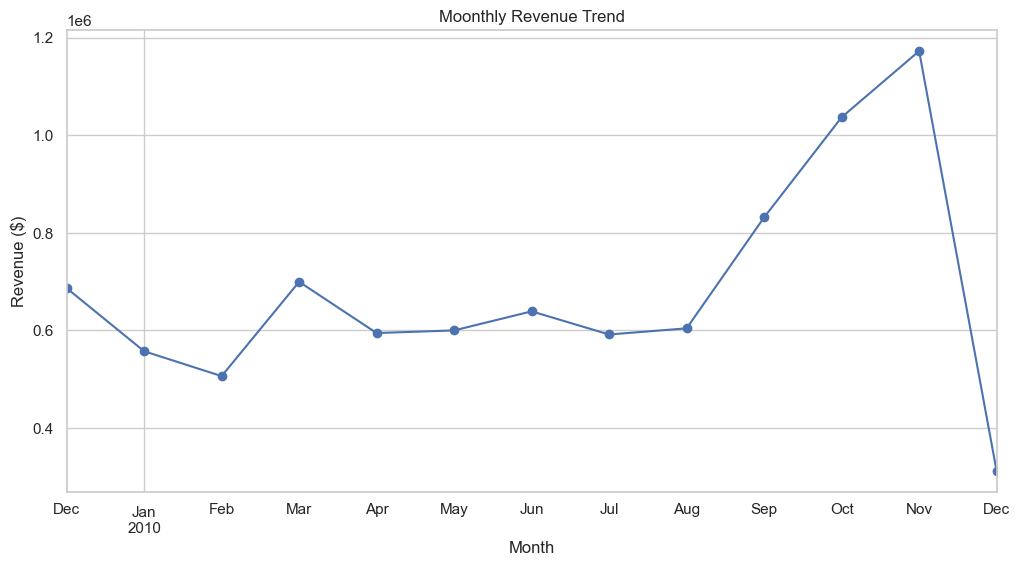

In [17]:
#Time-Based Trends
from pandas.core.resample import get_resampler

#set style
sns.set_theme(style="whitegrid")

#grow by month
monthly_revenue = df.set_index('InvoiceDate')['TotalAmount'].resample('ME').sum()

plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line',marker='o',color='b')
plt.title('Moonthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.show()

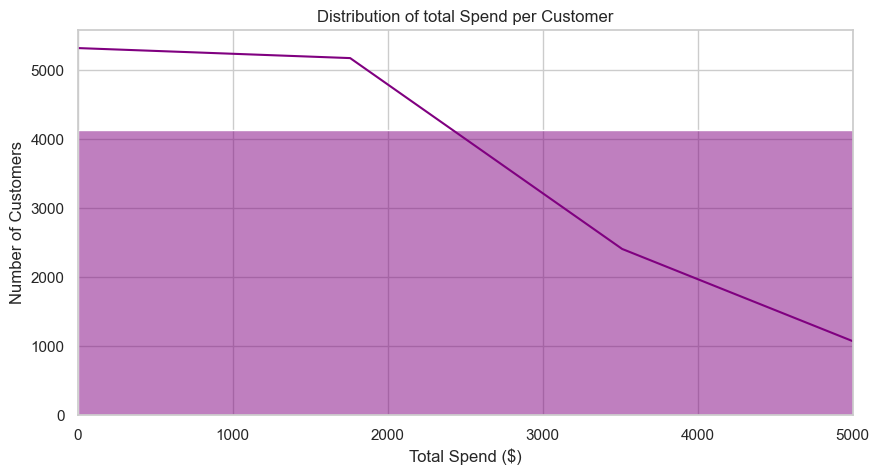

In [18]:
#customer level distribution

customer_spend = df.groupby('Customer ID')['TotalAmount'].sum()
plt.figure(figsize=(10, 5))
sns.histplot(customer_spend, bins=50, kde=True, color='purple')
plt.title('Distribution of total Spend per Customer')
plt.xlabel('Total Spend ($)')
plt.ylabel('Number of Customers')
plt.xlim(0,5000)
plt.show()

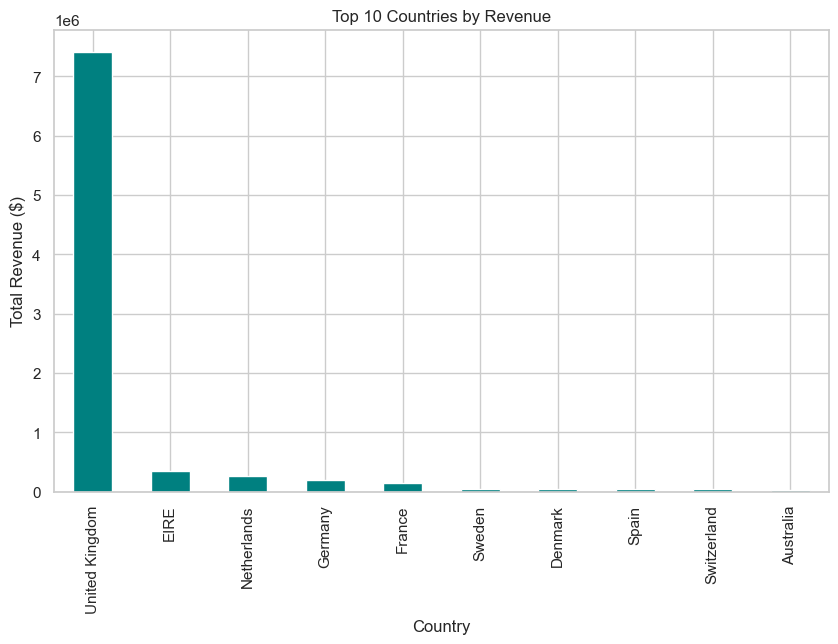

In [19]:
#Geographical analysis
country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
country_revenue.plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Total Revenue ($)')
plt.show()

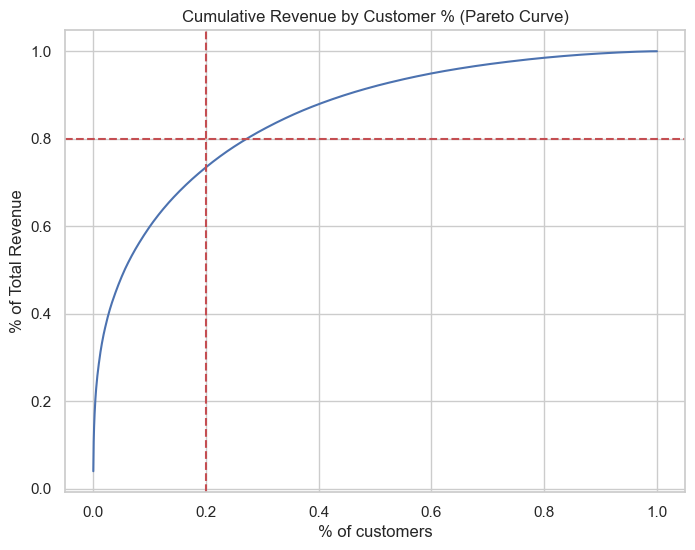

In [20]:
# Pareto Principal -> to find the power users
# top 20% customers generate 80% of the revenue

sorted_spend = customer_spend.sort_values(ascending = False)
cumulative_spend = sorted_spend.cumsum()/total_revenue
percent_customers = np.arange(1, len(customer_spend) + 1)/len(customer_spend)

plt.figure(figsize=(8,6))
plt.plot(percent_customers, cumulative_spend)
plt.axvline(0.2, color='r', linestyle='--')
plt.axhline(0.8, color='r', linestyle='--')
plt.title('Cumulative Revenue by Customer % (Pareto Curve)')
plt.xlabel('% of customers')
plt.ylabel('% of Total Revenue')
plt.show()

In [21]:
#Snapshot date - 1 day after the latest transaction

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)


#Aggregate data by customer ID
customer_df = df.groupby('Customer ID').agg({
    'InvoiceDate':[
        lambda x: (snapshot_date - x.max()).days,
        lambda x: (snapshot_date - x.min()).days,
        'min',
        'max'
    ],
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
})

#Flatten the MultiIndex columns

customer_df.columns = [
    'Recency',
    'Tenancy',
    'FirstPurchaseDate',
    'LastPurchaseDate',
    'Frequency',
    'Monetary'
]

customer_df['AvgOrderValue'] = customer_df['Monetary']/customer_df['Frequency']

customer_df = customer_df.reset_index()

print(f"Customer Table Shape:{customer_df.shape}")
display(customer_df.head())

Customer Table Shape:(4312, 8)


,Customer ID,Recency,Tenancy,FirstPurchaseDate,LastPurchaseDate,Frequency,Monetary,AvgOrderValue
0,12346.0,165,361,2009-12-14 08:34:00,2010-06-28 13:53:00,11,372.86,33.896364
1,12347.0,3,40,2010-10-31 14:20:00,2010-12-07 14:57:00,2,1323.32,661.660000
2,12348.0,74,74,2010-09-27 14:59:00,2010-09-27 14:59:00,1,222.16,222.160000
3,12349.0,43,225,2010-04-29 13:20:00,2010-10-28 08:23:00,3,2671.14,890.380000
4,12351.0,11,11,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,300.930000


In [22]:
#save this csv
customer_df.to_csv('../data/processed/02_customer_table.csv',index=False)
print("Customer-level table saved.")

Customer-level table saved.


### RFM and initial segmentation

In [23]:
# 1-5 scores for Rcency
customer_df['R_Score'] = pd.qcut(customer_df['Recency'], 5, labels = [5,4,3,2,1])

#1-5 scores for frequency and monetary
customer_df['F_Score'] = pd.qcut(customer_df['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
customer_df['M_Score'] = pd.qcut(customer_df['Monetary'],5, labels=[1,2,3,4,5])

customer_df['RFM_Group'] = (customer_df['R_Score'].astype(str)+
                            customer_df['F_Score'].astype(str)+
                            customer_df['M_Score'].astype(str))

# total numerical Score
customer_df['Total_Score'] = customer_df[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

In [24]:
def assign_segment(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])
    if r>=4 and f>=4:
        return 'Champions'
    elif r>=3 and f>=3:
        return 'Loyal Customer'
    elif r>=4 and f <= 2:
        return 'Recent Customer'
    elif r<=2 and f>=4:
        return 'At Risk'
    elif r<=2 and f<=2:
        return 'Lost'
    else:
        return 'Avetage/Standard'
    

customer_df['Segment'] = customer_df.apply(assign_segment, axis=1)

C:\Users\hpp\AppData\Local\Temp\ipykernel_3660\2935845627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer_df, x='Segment', palette='viridis', order=customer_df['Segment'].value_counts().index)


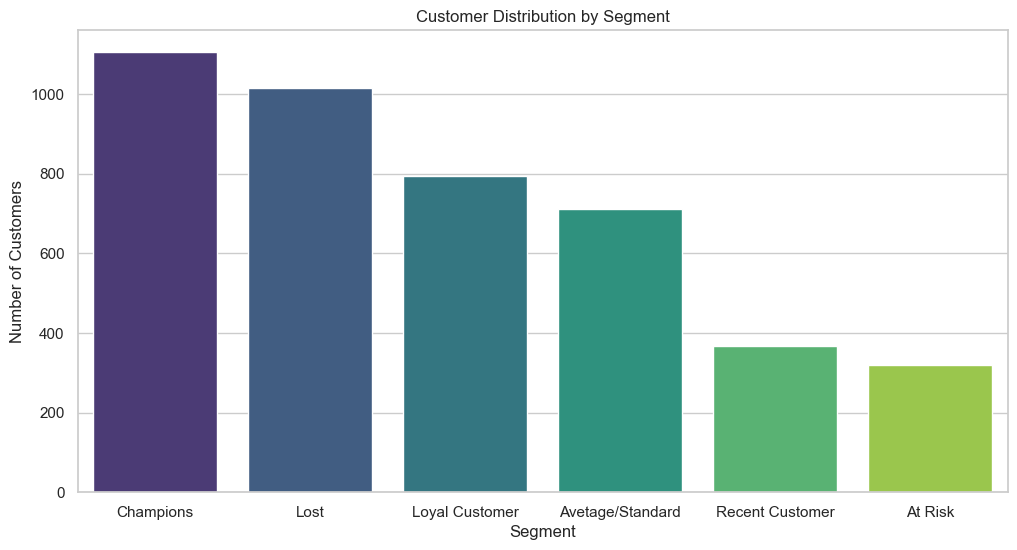

,Recency,Frequency,Monetary,Count
Segment,,,,
At Risk,134.371875,5.340625,2282.663097,320
Avetage/Standard,109.683544,1.804501,651.171406,711
Champions,14.121267,10.453394,5298.494559,1105
Lost,213.884729,1.126108,403.977836,1015
Loyal Customer,40.525189,3.842569,1497.486135,794
Recent Customer,19.822888,1.297003,503.243134,367


In [25]:
plt.figure(figsize=(12, 6))
sns.countplot(data=customer_df, x='Segment', palette='viridis', order=customer_df['Segment'].value_counts().index)
plt.title('Customer Distribution by Segment')
plt.ylabel('Number of Customers')
plt.show()

# Show average spend per segment
segment_analysis = customer_df.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer ID': 'count'
}).rename(columns={'Customer ID': 'Count'})

display(segment_analysis)

In [26]:
customer_df.to_csv('../data/processed/03_rfm_segmented_customers.csv', index=False)

## 90 Day - churn stratgy

### Recency > 90  -> churn = 1
### Recency <= 90  -> churn = 0

In [27]:
CHURN_DAYS = 90

customer_df['Churn'] = customer_df['Recency'].apply(lambda x: 1 if x > CHURN_DAYS else 0)

churn_counts = customer_df['Churn'].value_counts(normalize = True) * 200
print(f"active  Customers(0): {churn_counts[0]:.2f}%")
print(f"Churned  Customers(1): {churn_counts[1]:.2f}%")

active  Customers(0): 133.44%
Churned  Customers(1): 66.56%


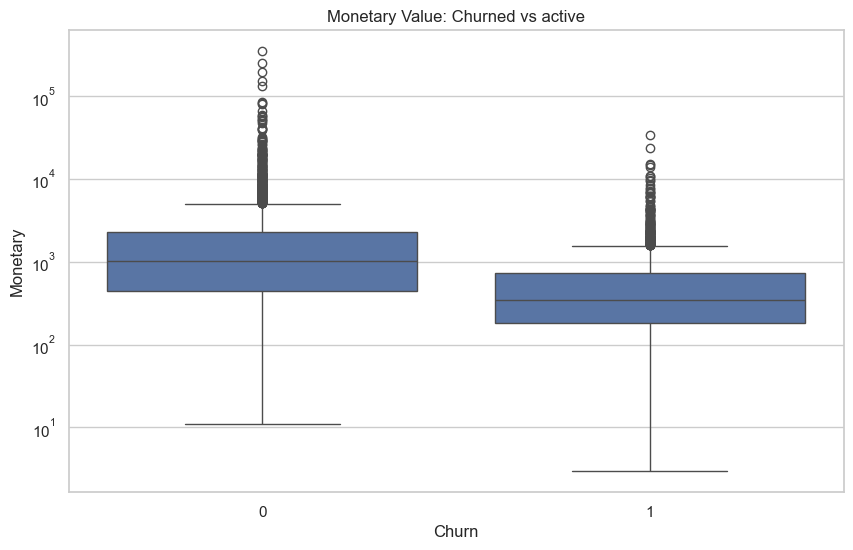

In [28]:
#EDA on churn

plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y='Monetary', data=customer_df)
plt.title("Monetary Value: Churned vs active")
plt.yscale('log')
plt.show()

In [29]:
# Calculate average days between orders per customer
# We go back to the original 'df' for this
df_sorted = df.sort_values(['Customer ID', 'InvoiceDate'])
df_sorted['PrevOrderDate'] = df_sorted.groupby('Customer ID')['InvoiceDate'].shift(1)
df_sorted['DaysBetween'] = (df_sorted['InvoiceDate'] - df_sorted['PrevOrderDate']).dt.days

# Aggregate and merge back to customer_df
avg_gap = df_sorted.groupby('Customer ID')['DaysBetween'].mean().reset_index()
avg_gap.columns = ['Customer ID', 'AvgDaysBetweenOrders']

customer_df = customer_df.merge(avg_gap, on='Customer ID', how='left')
customer_df['AvgDaysBetweenOrders'] = customer_df['AvgDaysBetweenOrders'].fillna(0)

In [30]:
customer_df.to_csv('../data/processed/04_features_and_target.csv', index=False)
print("Master modeling table saved.")

Master modeling table saved.


### Basic Fature Selection

In [31]:
features = [
    'Recency', 
    'Frequency', 
    'Monetary', 
    'Tenancy', 
    'AvgOrderValue', 
    'AvgDaysBetweenOrders'
]

X = customer_df[features]
y = customer_df['Churn']

print('Feature selected for modeling.')

Feature selected for modeling.


In [32]:
#Apply log transformation to skewed features
# we add +1 beacause log(0) is undefined

X_transformed = X.copy()
X_transformed['Monetary'] = np.log1p(X_transformed['Monetary'])
X_transformed['Frequency'] = np.log1p(X_transformed['Frequency'])
X_transformed['AvgOrderValue'] = np.log1p(X_transformed['AvgOrderValue'])

print("Skewed  features transformed.")

Skewed  features transformed.


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
display(X_scaled_df.head())

,Recency,Frequency,Monetary,Tenancy,AvgOrderValue,AvgDaysBetweenOrders
0,0.762299,1.613017,-0.540688,1.139703,-2.814176,0.286569
1,-0.910402,-0.394693,0.447651,-1.560147,1.157360,-0.270621
2,-0.177305,-0.981910,-0.943904,-1.274181,-0.310945,-0.324449
3,-0.497389,0.021945,0.996204,-0.004159,1.557374,-0.142958
4,-0.827799,-0.981910,-0.707671,-1.804058,0.096891,-0.324449


In [34]:
import joblib

joblib.dump(scaler,'../models/preprocessor.pkl')
print("Scaler saved for future use.")

Scaler saved for future use.


### 80/20 split: 80% for training and 20% for testing

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size: {X_test.shape[0]} customers")

Training set size: 3449 customers
Testing set size: 863 customers


In [36]:
#verfication that churn percentage is consistent across both sets
print("Churn Rate in training Set:{:.2f}%".format(y_train.mean()*100))
print("Churn Rate in testing Set: {:.2f}%".format(y_test.mean()*100))

Churn Rate in training Set:33.29%
Churn Rate in testing Set: 33.26%


In [37]:
#save the splits
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Split data  saved successfully.")

Split data  saved successfully.


## 03_modeling/ipynb

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Initialize the model
# 'balanced' class_weight helps if you have more active customers than churned ones
model = LogisticRegression(class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [39]:
#Performance Evaluation

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability of churn

# Print metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.2f}")

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       576
           1       0.99      1.00      0.99       287

    accuracy                           1.00       863
   macro avg       0.99      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863

ROC-AUC Score: 1.00


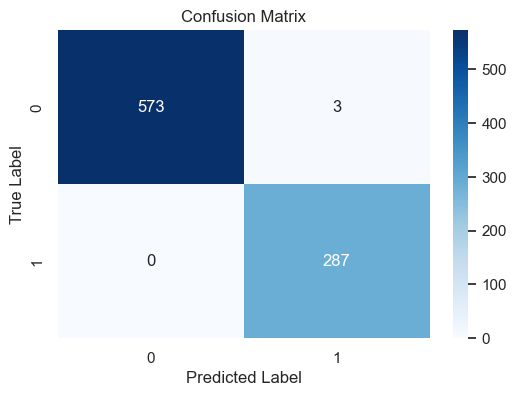

In [40]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

C:\Users\hpp\AppData\Local\Temp\ipykernel_3660\3187875375.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette='magma')


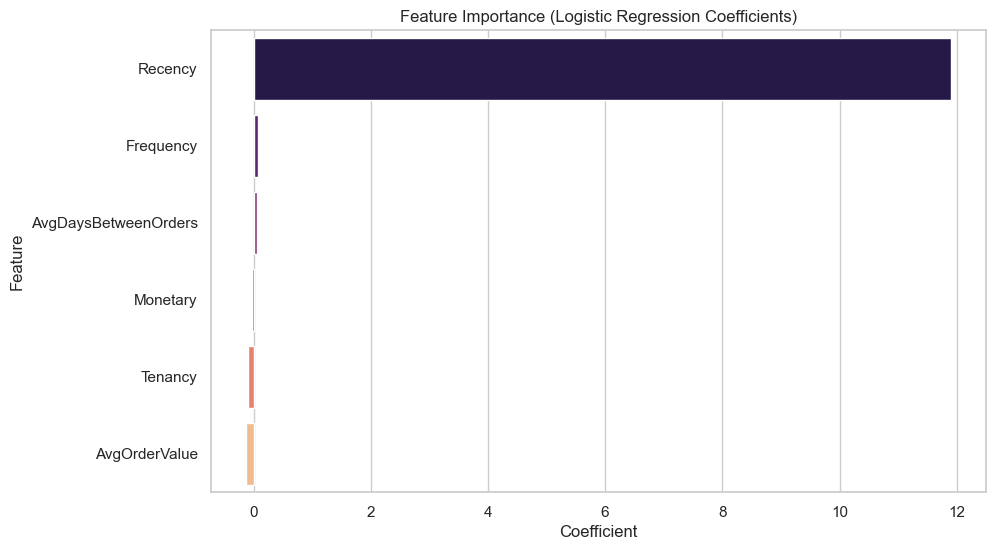

In [41]:
# Get coefficients
importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='magma')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.show()

In [42]:
import joblib

# Save the model
joblib.dump(model, '../models/churn_model.pkl')
print("Model saved to models/churn_model.pkl")

Model saved to models/churn_model.pkl


In [43]:
# Load your model and scaler
model = joblib.load('../models/churn_model.pkl')
scaler = joblib.load('../models/preprocessor.pkl')

# Use the full scaled feature set from Phase 7
all_customers_probs = model.predict_proba(X_scaled_df)[:, 1]

# Add the probabilities back to the original customer table
customer_df['Churn_Probability'] = all_customers_probs

In [47]:
def define_risk_level(prob):
    if prob > 0.8:
        return 'Critical'
    elif prob > 0.5:
        return 'High Risk'
    elif prob > 0.2:
        return 'Low Risk'
    else:
        return 'Safe'

customer_df['Risk_Level'] = customer_df['Churn_Probability'].apply(define_risk_level)


In [48]:
risk_summary = customer_df.groupby('Risk_Level').agg({
    'Customer ID': 'count',
    'Monetary': 'sum',
    'Recency': 'mean'
}).rename(columns={'Customer ID': 'Customer_Count', 'Monetary': 'Revenue_At_Risk'})

# Calculate what percentage of total revenue is at risk
total_rev = risk_summary['Revenue_At_Risk'].sum()
risk_summary['Revenue_Percentage'] = (risk_summary['Revenue_At_Risk'] / total_rev) * 100

display(risk_summary)

,Customer_Count,Revenue_At_Risk,Recency,Revenue_Percentage
Risk_Level,,,,
Critical,1341,971699.994,215.792692,11.002034
High Risk,110,118771.890,94.145455,1.344790
Low Risk,141,144518.540,82.588652,1.636305
Safe,2720,7597012.850,30.056618,86.016871


In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib

# 1. Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=3, # Adjusts for imbalanced churn classes
    use_label_encoder=False,
    eval_metric='logloss'
)

# 2. Fit Model
xgb_model.fit(X_train, y_train)

# 3. Evaluate
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.2f}")

# 4. Save the advanced model
joblib.dump(xgb_model, '../models/churn_xgb.pkl')

d:\customer-intelligence\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:40:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost ROC-AUC: 1.00


['../models/churn_xgb.pkl']

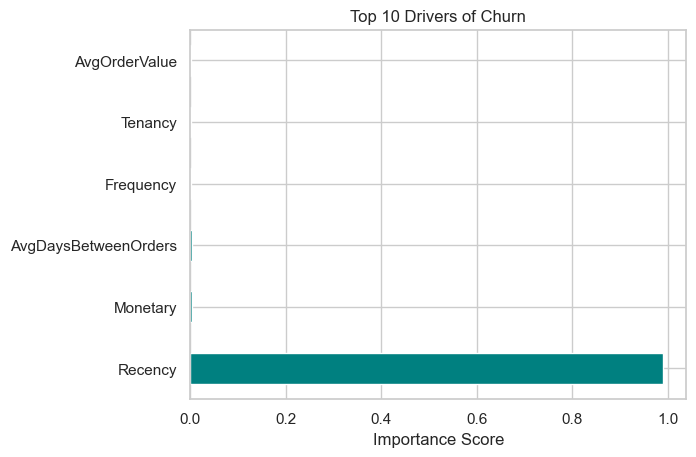

In [50]:
import matplotlib.pyplot as plt

# Plotting top features
feat_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of Churn')
plt.xlabel('Importance Score')
plt.show()